y = a + bx

where,
x is an Independent Variable, Plotted along the X-axis
y is the Dependent Variable, Plotted along the Y-axis

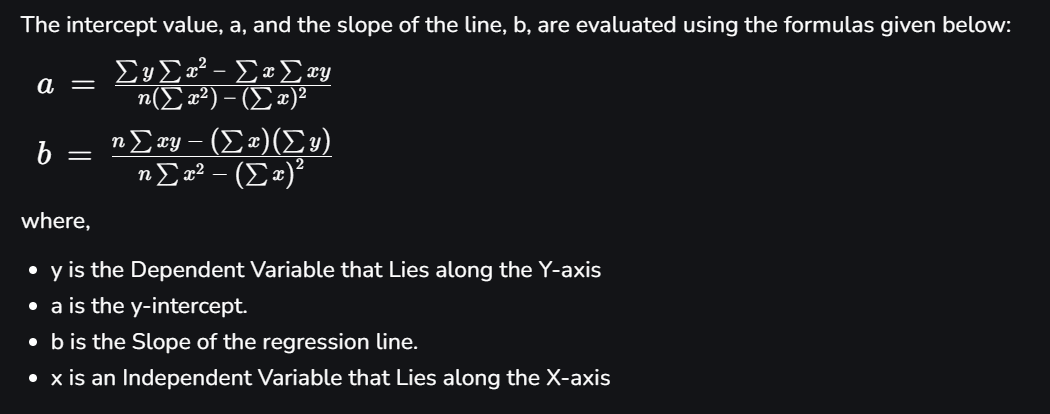

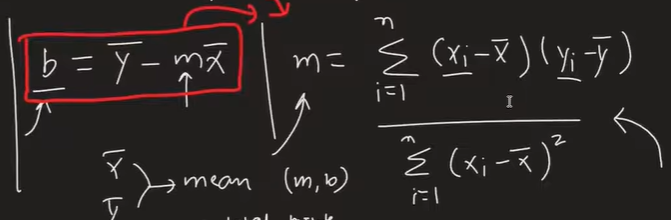

In [1]:
import numpy as np
import pandas as pd

In [2]:
# dataset = pd.read_csv('data_01.csv')

In [3]:
# dataset.head()

In [4]:
# X = dataset.iloc[:, :-1].values
# print(X)

X = dataset.iloc[:, :-1].values uses pandas' integer-location indexer .iloc to select all rows (:) and all columns except the last (:-1). That slice returns a DataFrame containing the feature columns; calling .values converts it to a NumPy array (shape (n_samples, n_features)), which is the usual input matrix X for scikit‑learn models.

In [5]:
# y = dataset.iloc[:, -1].values
# print(y)

y = dataset.iloc[:, -1].values selects all rows (:) and the last column only (-1) via .iloc. That returns the target column; .values converts it to a NumPy 1‑D array (shape (n_samples,)), which is used as the label vector y.

The above code reads a CSV file named 'data_01.csv' using pandas, extracts the features (X) and 
target variable (y) from the dataset, and prints them. Since the csv file does not have a header, 
we can directly use numpy to load the data and split it into X and y.

In [6]:
filePath = 'data_01.csv'

In [7]:
dataset = np.loadtxt(filePath, delimiter=",", skiprows=0)
# If the first row is NaN (header), skip it
if np.isnan(dataset[0]).any():
    dataset = np.loadtxt(filePath, delimiter=",", skiprows=1)
X = dataset[:, 0]
y = dataset[:, 1]

print(X)
print(y)

[14.96 25.18  5.11 ... 31.32 24.48 21.6 ]
[463.26 444.37 488.56 ... 429.57 435.74 453.28]


In [8]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [10]:
class SimpleLinearRegression:
    def __init__(self):
        self.m = None   #here m is the slope of the line
        self.b = None   #here b is the intercept of the line
        
    def fit(self, X_train, y_train):
        num = 0
        den = 0
        
        for i in range(len(X_train)):
            num = num + (X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean())
            den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())
        
        self.m = num / den
        self.b = y_train.mean() - self.m * X_train.mean()
    
    def predict(self, X_predict):
        y_pred = self.m * X_predict + self.b
        return y_pred

In [11]:
X_train

array([16.91, 28.8 , 25.76, ..., 32.46, 33.11, 15.63], shape=(7654,))

In [12]:
y_train

array([465.86, 426.87, 443.7 , ..., 427.87, 431.77, 455.24], shape=(7654,))

In [13]:
slr = SimpleLinearRegression()

In [15]:
slr.fit(X_train, y_train)

In [17]:
slr.m

np.float64(-2.1683324565914237)

In [18]:
slr.b

np.float64(496.97882521137024)

In [21]:
y_pred = slr.predict(X_test)

In [54]:
from sklearn.metrics import r2_score

In [22]:
r2_score(y_test, y_pred)

0.9020027267172197

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
sklearn_slr = LinearRegression()

In [33]:
X_train

array([16.91, 28.8 , 25.76, ..., 32.46, 33.11, 15.63], shape=(7654,))

In [70]:
X_train_reshaped = X_train.reshape(-1, 1) 
#sklearn's LinearRegression expects a 2D array for the features, 
#so we reshape X_train to have one column and as many rows as needed.

In [ ]:
print(X_train_reshaped)

[16.91]


In [49]:
sklearn_slr.fit(X_train_reshaped, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_pred_sklearn = sklearn_slr.predict(X_test.reshape(-1, 1))

In [51]:
sklearn_slr.coef_

array([-2.16833246])

In [60]:
sklearn_slr.intercept_

np.float64(496.9788252113703)

In [66]:
r2_score(y_test, y_pred_sklearn)

0.9020027267172197

What reshape(-1, 1) means

-1: let NumPy infer the correct number of rows to preserve total size.

1 : force exactly one column (a column vector / 2‑D array).
Practical significance

Shape difference: 1‑D array → (n,); single‑feature 2‑D array → (n, 1).
Indexing: X[0] is a scalar (e.g., 1); X_col[0] is a 1‑element array (array([1])) — use X_col[0,0] for the scalar.
Libraries: scikit‑learn expects X as 2‑D (n_samples, n_features). Use reshape(-1, 1) (or X[:, None]) to convert a 1‑D feature vector into the required shape before fit()/predict().
Memory: reshape may return a view (not always a copy); it does not modify the original array in place.

In [74]:
X = np.array([1, 2, 3, 4])
print(X.shape)        # (4,)
print(X)              # [1 2 3 4]

X_col = X.reshape(-1, 1)
print(X_col.shape)    # (4, 1)
print(X_col)
print(X_col[0,0])
# [[1]
#  [2]
#  [3]
#  [4]]

(4,)
[1 2 3 4]
(4, 1)
[[1]
 [2]
 [3]
 [4]]
1
